Se importaron los datos del archivo "Tiempos.csv" y se generó una gráfica de dispersión para visualizar el comportamiento de los datos.

      Tiempo  Calificacion
0  85.076389          85.0
1  84.675556          85.0
2  79.553889         110.0
3  75.310556         110.0
4  64.958611         110.0


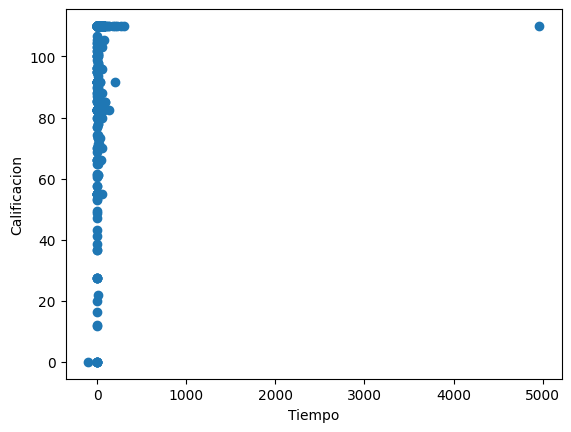

In [2]:
import pandas as pd
data =pd.read_csv("Tiempos1.csv")
print(data.head())
import matplotlib.pyplot as plt
plt.scatter(data['Tiempo'],data['Calificacion'])
plt.xlabel("Tiempo")
plt.ylabel("Calificacion")
plt.show()

La primera vez tratando de hacer la gráfica me salió este error: ***'value' must be an instance of str or bytes, not a float***. Pensé que la base de datos podría tener variables que fueran string o huecos, así que la revisé...
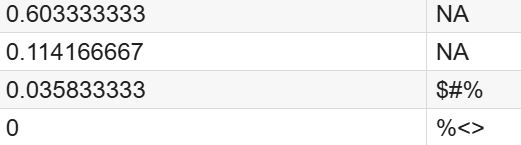


Efectivamente, la base de datos tenía tanto huecos como strings, lo que hice fue editar la base de datos al sustituir esos datos por la media.

Ahora, al poder ya graficarlo, nos damos cuenta que hay un punto que se ve muuuuuuuy alejado de lo "normal", nos damos cuenta rápidamente que es un outlier, así que lo borraremos de la base de datos. Usaré el método de Tukey para outliers (para hacerlo en el código y no sólo manualmente)

In [3]:
import numpy as np
Q1 = data['Tiempo'].quantile(0.25)
Q3 = data['Tiempo'].quantile(0.75)
IQR = Q3 - Q1
li = Q1 - 8 * IQR  # Límite inferior
ls = Q3 + 8 * IQR  # Límite superior

# El 8 está para que solamente me identifique outliers de aproximadamente
# +120 horas antes de la entrega... me identificaba antes otros outliers
# (usando k=1.5 o 3)... pero eran de 70-80 horas, que me parece algo
# que todavía debería entrar dentro de lo "normal" (bajo mi criterio)

outliers = data[(data['Tiempo'] < li) | (data['Tiempo'] > ls)]
print("Outliers encontrados:")
print(outliers)

Outliers encontrados:
          Tiempo  Calificacion
29   4960.167000     110.00000
54    124.434722     110.00000
81    132.637500     110.00000
107  -100.000000       0.00000
108   177.090000     110.00000
135   299.986667     110.00000
136   220.310833     110.00000
137   202.196111      91.66666
138   199.105833     110.00000
270   102.745278     110.00000
324   269.995278     110.00000
378   135.675833      82.50000


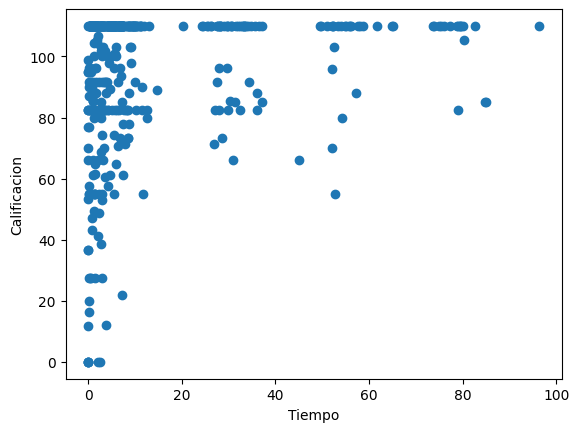

In [4]:
data = data[~((data['Tiempo'] < li) | (data['Tiempo'] > ls))] # borrar outliers del dataset
plt.scatter(data['Tiempo'],data['Calificacion'])
plt.xlabel("Tiempo")
plt.ylabel("Calificacion")
plt.show()

Viendo la dispersión de los datos, parece que hay ciertos patrones no lineales, pero me doy cuenta que la primera parte de los datos, se comporta diferente a la segunda parte... se podría representar con un modelo de splines tal vez.

Se separaron los datos en entrenamiento y prueba, utilizando una relación de 70/30. Luego, se imprimieron en consola los promedios de los tiempos y las calificaciones para ambos conjuntos.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data[['Tiempo']], data['Calificacion'], test_size=0.3, random_state=42)
trainx_mean = X_train.mean()
testx_mean = X_test.mean()

print("Tiempo train: ",trainx_mean)
print("Tiempo test: ",testx_mean)
trainy_mean = y_train.mean()
testy_mean = y_test.mean()

print("Calificaciones train: ",trainy_mean)
print("Calificaciones test: ",testy_mean)

Tiempo train:  Tiempo    13.09888
dtype: float64
Tiempo test:  Tiempo    15.022443
dtype: float64
Calificaciones train:  94.05400738095238
Calificaciones test:  96.26739325396825


Nos damos cuenta que en general, los datos que se usan para test, son mayores... el promedio no varía mucho entre ellos, pero igual podemos ver una pequeña diferencia. Creo que como es una diferencia muy pequeña, no debería afectar mucho en nuestro modelo, en caso de que fuera muy grande, probaríamos con datos muy diferentes a los que se usaron para entrenamiento, lo que nos daría una menor precisión.

Se entrenó un modelo de regresión polinomial utilizando los datos de entrenamiento, eligiendo el orden de polinomial más adecuado según los datos.

In [24]:
#!pip install statsmodels
import statsmodels.api as sm

X_train, X_test, y_train, y_test = train_test_split(data[['Tiempo']], data['Calificacion'], test_size=0.3, random_state=42)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

pol = PolynomialFeatures(2)
xp_train = pol.fit_transform(X_train)
xp_test = pol.fit_transform(X_test)

model = sm.OLS(y_train, sm.add_constant(xp_train)).fit()
predy = model.predict(sm.add_constant(xp_test))
print(model.summary())

r2 = r2_score(y_test, predy)
print("R2: ",r2)

                            OLS Regression Results                            
Dep. Variable:           Calificacion   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     9.444
Date:                Wed, 12 Feb 2025   Prob (F-statistic):           0.000106
Time:                        22:09:06   Log-Likelihood:                -1350.9
No. Observations:                 294   AIC:                             2708.
Df Residuals:                     291   BIC:                             2719.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.1243      1.997     44.127      0.0

x1 (coef. del tiempo): 0.7566 --> Por cada unidad de aumento en el tiempo, la calificación sube 0.7566 puntos, en promedio. Es significativo (p = 0.001).

x2 (coef. del tiempo²): -0.0072 --> Como es negativo, sugiere que, después de cierto punto, más tiempo podría reducir la calificación. Es significativo (p = 0.021).

El R² es muy bajo, lo que indica que el modelo no explica bien la variabilidad en la calificación. Pienso que faltan muchas más variables que intervienen que no son solo el tiempo de entrega.

Se instaló la librería mlinsights y se utilizó el modelo PiecewiseRegressor con la estrategia de "bins" para entrenar un modelo de regresión segmentada, utilizando regresiones cuadráticas para cada segmento. El modelo fue ajustado con los datos de entrenamiento (xp_train) y luego se generaron las predicciones sobre el conjunto de prueba (xp_test). Las predicciones obtenidas se almacenaron en ypred_seg.

In [36]:
#!pip install mlinsights
from mlinsights.mlmodel import PiecewiseRegressor
xp_train = pd.DataFrame(xp_train)
xp_test = pd.DataFrame(xp_test)
model_seg = PiecewiseRegressor('bins').fit(xp_train.iloc[:,1:], y_train)
ypred_seg = model_seg.predict(xp_test.iloc[:,1:])

Se entrenó un modelo KNN para regresión utilizando el valor de 𝑘 que se consideró adecuado. Se probaron varios valores de 𝑘 para evaluar cuál ofrece un mejor rendimiento.



In [37]:
from sklearn.neighbors import KNeighborsRegressor as KNN
model_knn10 = KNN(n_neighbors=10).fit(X_train, y_train)
ypred_knn10 = model_knn10.predict(X_test)

model_knn15 = KNN(n_neighbors=15).fit(X_train, y_train)
ypred_knn15 = model_knn15.predict(X_test)

model_knn20 = KNN(n_neighbors=20).fit(X_train, y_train)
ypred_knn20 = model_knn20.predict(X_test)

# usé 3 valores diferentes para probar cuál es mejor

Se calculó el RSE (Root Square Error) para los tres modelos entrenados (Regresión Polinomial, Regresión Segmentada y KNN) en los datos de prueba y se compararon los resultados.

In [46]:
# Modelo polinomial
p_poly = xp_train.shape[1] - 1
RSS_poly = np.sum((y_test - predy) ** 2)
RSE_poly = np.sqrt(RSS_poly / (len(y_test) - p_poly - 1))
print("RSE polinomial: ", RSE_poly)

# Modelo segmentado
p_seg = xp_train.shape[1] - 1
RSS_seg = np.sum((y_test - ypred_seg) ** 2)
RSE_seg = np.sqrt(RSS_seg / (len(y_test) - p_seg - 1))
print("RSE segmentado: ", RSE_seg)

# Modelos KNN
RSS_knn10 = np.sum((y_test - ypred_knn10) ** 2)
RSE_knn10 = np.sqrt(RSS_knn10 / (len(y_test) - 1))
print("RSE KNN 10: ", RSE_knn10)

RSS_knn15 = np.sum((y_test - ypred_knn15) ** 2)
RSE_knn15 = np.sqrt(RSS_knn15 / (len(y_test) - 1))
print("RSE KNN 15: ", RSE_knn15)

RSS_knn20 = np.sum((y_test - ypred_knn20) ** 2)
RSE_knn20 = np.sqrt(RSS_knn20 / (len(y_test) - 1))
print("RSE KNN 20: ", RSE_knn20)

RSE polinomial:  20.971856834671648
RSE segmentado:  19.285960884564044
RSE KNN 10:  19.25029679091595
RSE KNN 15:  18.884301237102697
RSE KNN 20:  18.970613851951757


Si tomamos en cuenta tanto la precisión como la interpretabilidad, el modelo segmentado sería la mejor opción. Aunque el modelo KNN con k=15 ofrece la mayor precisión, su naturaleza basada en vecinos cercanos lo hace menos interpretable. En cambio, el modelo segmentado permite comprender cómo varía la relación entre "Tiempo" y "Calificación" en diferentes intervalos, ofreciendo una mayor claridad sobre los patrones. El modelo polinomial de segundo grado es el que tiene mayor error, así que lo podemos descartar.

Se graficaron las calificaciones reales junto con las predicciones de los tres modelos (Polinomial, Segmentado y KNN) en un solo gráfico.

<ipython-input-54-b2a42cd8a0a8>:4: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test, predy, label='Polinomial', color='red', s=50, alpha=0.6, edgecolors='w', marker='x')


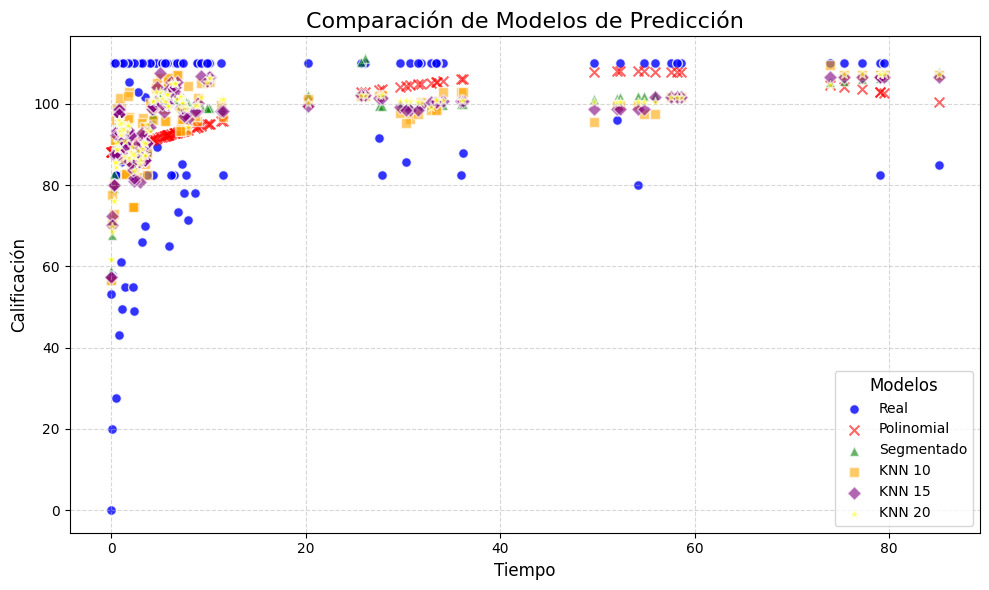

In [54]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Real', color='blue', s=50, alpha=0.8, edgecolors='w', marker='o')
plt.scatter(X_test, predy, label='Polinomial', color='red', s=50, alpha=0.6, edgecolors='w', marker='x')
plt.scatter(X_test, ypred_seg, label='Segmentado', color='green', s=50, alpha=0.6, edgecolors='w', marker='^')
plt.scatter(X_test, ypred_knn10, label='KNN 10', color='orange', s=50, alpha=0.6, edgecolors='w', marker='s')
plt.scatter(X_test, ypred_knn15, label='KNN 15', color='purple', s=50, alpha=0.6, edgecolors='w', marker='D')
plt.scatter(X_test, ypred_knn20, label='KNN 20', color='yellow', s=50, alpha=0.6, edgecolors='w', marker='*')
plt.title('Comparación de Modelos de Predicción', fontsize=16)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Calificación', fontsize=12)
plt.legend(title='Modelos', loc='lower right', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# aclaración: usé chat GPT para personalizar mejor la gráfica
